# Bank Customer Churn Prediction

The aim of this project to analyze the bank customer's demographics and financial
information which inculdes customer's age, gender. country, credit score, balance and
many others to predict whether the customer will leave the bank or not

In [1]:
# import the libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading the datasets
df = pd.read_csv("churn.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Data Preprocessing 1

In [3]:
# checking the shape of the data 
df.shape

(10000, 14)

Dropping the unecessary columns - RowNumber, CustomerID, Surname

In [4]:
df.drop(['RowNumber', "CustomerId", "Surname"], axis=1, inplace=True)

In [5]:
df.shape

(10000, 11)

Checking the null values 

In [6]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Checking the datatypes of the columns

In [7]:
df.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

checking the duplicate values

In [8]:
df.duplicated().sum()

0

Renaming the column "Exited" to "Churn"

In [9]:
df.rename(columns= {"Exited": "Churn"}, inplace=True)

In [10]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
# Descriptive statistics

df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


# EDA

In the exploratory data analysis, I will be looking at the distribution of the data, the
coorelation between features and the target variable and the relationship between the
features and the target variable. I will start by looking at the distribution of the data,
followed by the relationship between the features and the target variable.

Pie chart for customer churn

In [12]:
df.Churn.value_counts()

Churn
0    7963
1    2037
Name: count, dtype: int64

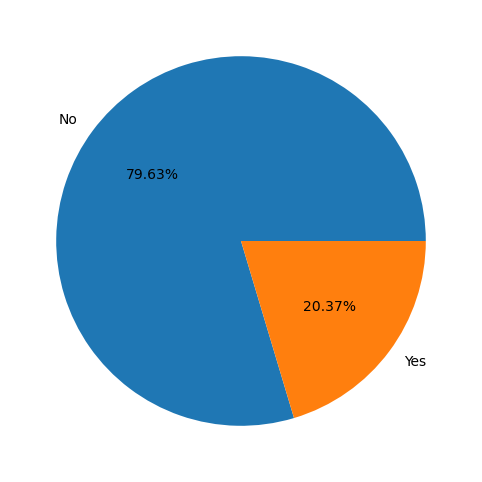

In [13]:
plt.figure(figsize=(10,6))
plt.pie(df['Churn'].value_counts(), labels=[ "No", "Yes"],autopct='%1.2f%%')
plt.show()

The pie chart clearly visulaizes the customer churn in the dataset. The majority of the
customers in the dataset continue to use the serivces of the bank with only 20.4% of the
customers churning.

#### Gender

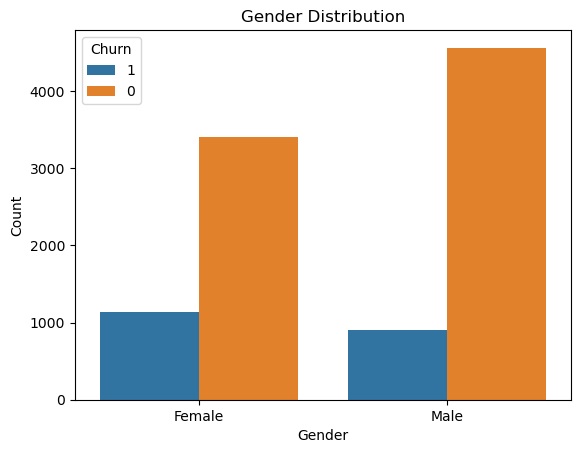

In [14]:
# gender and customer churn

sns.countplot(x = "Gender", data=df, hue=df['Churn'].astype(str))
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

As shown in the graph, majority of the customers are male. But upon looking at the
customer churn, we can see that females have more tendency to churn as compared to
males. However there is not much difference between the churn count of the two
genders so we cannot have a hypothesis regarding the customer churn based on the
gender of the customer.


### Age Distribution

C:\Users\memun\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Age', ylabel='Count'>

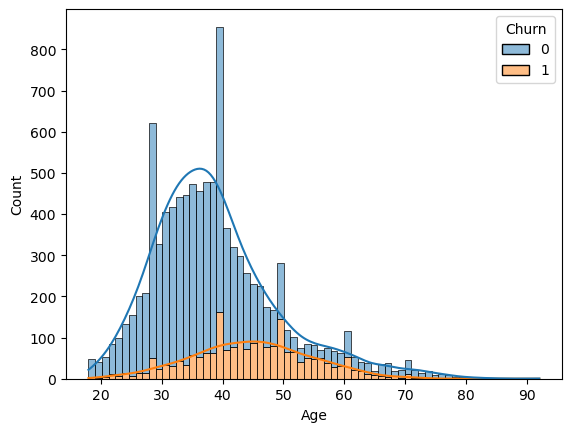

In [15]:
#histogram for age distribution 
sns.histplot(data=df , x='Age', hue='Churn', multiple='stack', kde=True)

This histtogram visualizes the age distribution and the churn count of the customers. The
majority of the customers are from age group 30-40 years old. However the customer
churn count is highest for the customersof age 40 and 50. In addition to that customers
from age group 20-25 years old count for the lowest churn count. Therefore, age plays a
significant role in customer churn, where late adults are more likely to churn as
compared to young adults with minimal churn count.


#### Credit Score

<Axes: xlabel='Churn', ylabel='CreditScore'>

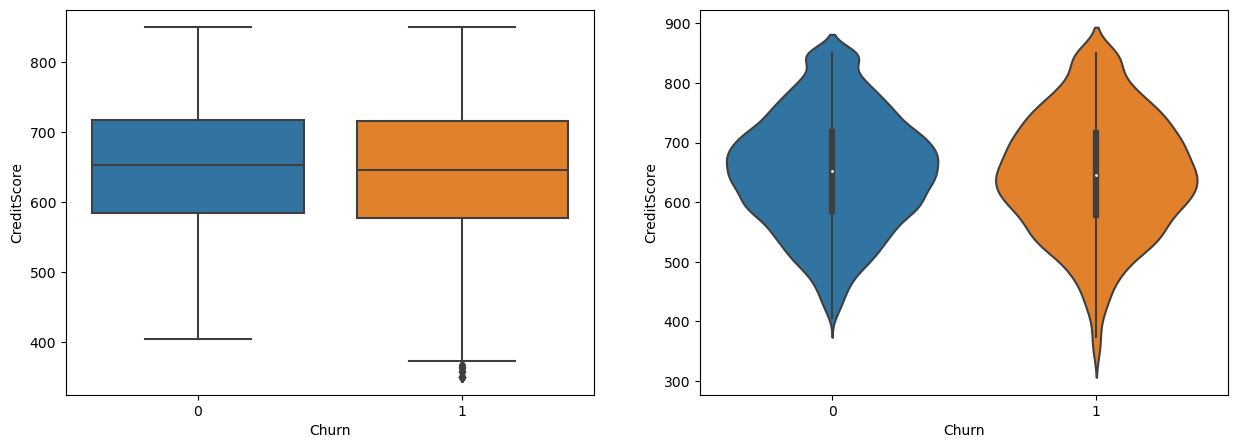

In [16]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
sns.boxplot(x="Churn", y="CreditScore", data=df, ax=ax[0])
sns.violinplot(x="Churn", y="CreditScore", data=df, ax=ax[1])

The boxplot and violinplot shows the distribution of curstomer's credit score along with
their churn. In the boxplot, the median of both the churn and non churn customers are almost same. In addition to that, the shape of violinplot is also similar for both the churn
and non churn customers. However some churn customers have low credit score, but on
the whole, the credit score is not a good indicator of churn.


#### Customer Location

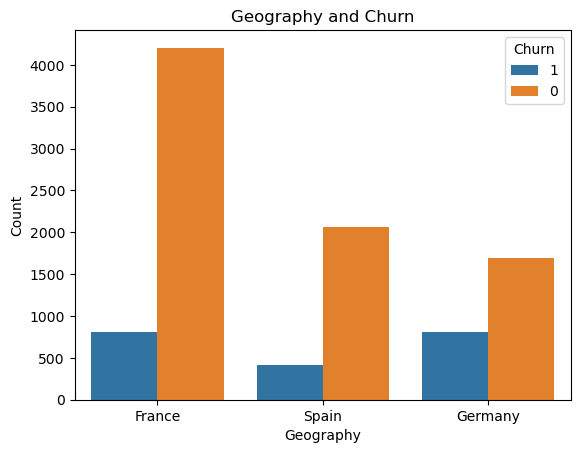

In [17]:
sns.countplot(x="Geography", hue = df["Churn"].astype(str), data=df)
plt.title("Geography and Churn")
plt.xlabel("Geography")
plt.ylabel("Count")
plt.show()

This graphs shows the number of customers from the their repective countries aling with
their churn count. Majority of the customers are from France, followed by Spain and
Germany. However in contrast to that Germany has the highest number of customer curn
followed by France and Spain. From this we can infer that German customers are more
likely to churn than the customers from other countries.


#### Tenure

<Axes: xlabel='Tenure', ylabel='count'>

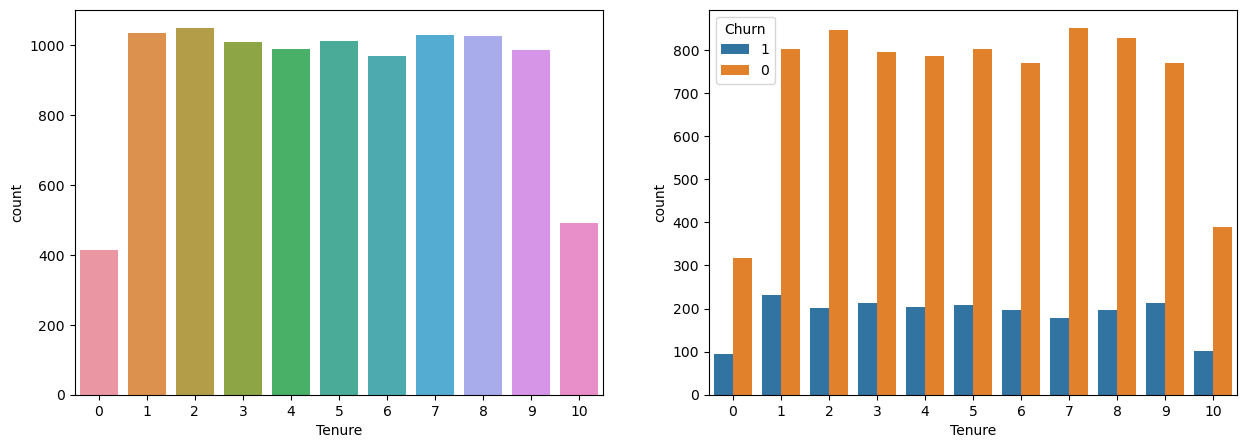

In [18]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
sns.countplot(x="Tenure", data = df, ax=ax[0])
sns.countplot(x="Tenure", hue=df["Churn"].astype(str), data = df, ax=ax[1])

Tensure refers to the time (in years) that a customer has been a client of the bank.
Majority of the customers in the dataset have a tenure between 1-9 years, having equal
distribution among them. There are very few customers with a tenure of less than 1 years
or more than 9 years. Looking at the churn of these customers based on their tenure, it
can be observed that customers with tenure 1-9 years have higher churn count with
maximum in customers with 1 year tenure followed those with 9 year tenure. However
customers more than 9 years on tenure counts for the least churn. This is because the
customers with higher tenure are more loyal to the bank and less likely to churn.

#### Bank Balance

C:\Users\memun\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Balance', ylabel='Count'>

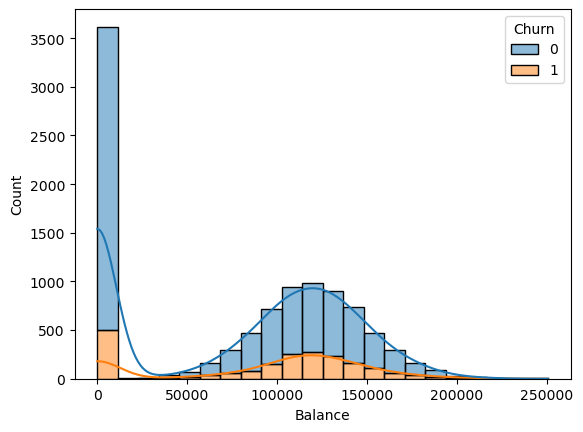

In [19]:
sns.histplot(data=df, x="Balance", hue="Churn", multiple = "stack", kde=True)

A huge number of customers have zero bank balance which also resulted in them leaving
the bank. However, customer having bank balance between 100000 to 150000 are more likely to leave the bank after the customers with zero bank balance.


#### Number of products purchased 

<Axes: xlabel='NumOfProducts', ylabel='count'>

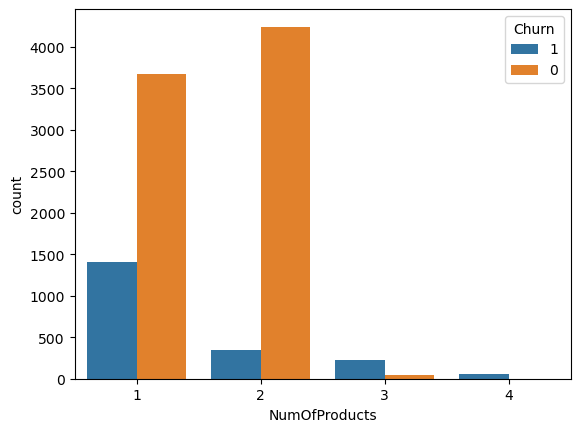

In [20]:
sns.countplot(x="NumOfProducts", hue=df["Churn"].astype(str), data=df)

In the dataset, we have customers in four categories according to the number of
products purchased. The customers with purchase or 1 or 2 products are highest in
number and have low churn count in comparison to the non churn customers in the
category. However, in the category where customers have purchased 3 or 4 products the
number of leaving customers is much higher than the non leaving customers. Therefore,
the number of product purchased is a good indicator of customer churn.

### Customers with/without credit card


<Axes: xlabel='HasCrCard', ylabel='count'>

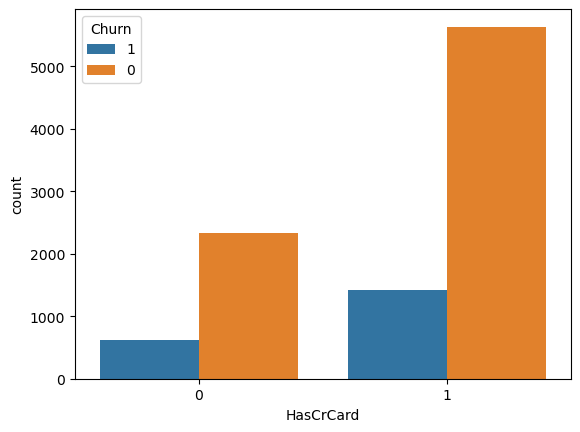

In [21]:
sns.countplot(x=df['HasCrCard'], hue= df['Churn'].astype(str))

Majoity of the customers have credit cars i.e. nealy 70% of the customers have credit
cards leaving 30% of the customers who do not have credit cards. Moreover, the number
of customers leaving the bank are more whom have a credit card.

### Active Members

<Axes: xlabel='IsActiveMember', ylabel='count'>

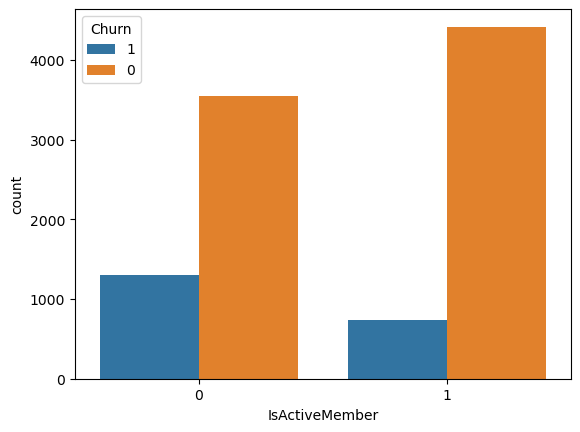

In [22]:
sns.countplot(x='IsActiveMember', hue = df['Churn'].astype(str), data=df)

As expected, the churn count is higher for non active members as compared to the
active members of the bank. This is because the active members are more satisfied with
the services of the bank and hence they are less likely to leave the bank. Therefore, the
bank should focus on the non active members and try to improve their services to retain
them.

#### Estimated Salary

C:\Users\memun\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='EstimatedSalary', ylabel='Count'>

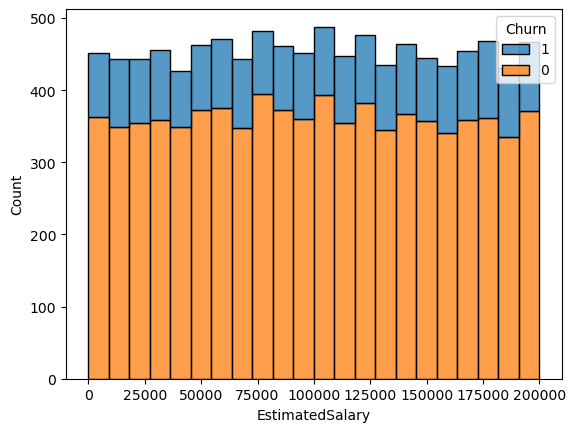

In [23]:
sns.histplot(data=df, x='EstimatedSalary', hue = df.Churn.astype(str), multiple="stack")

This graph shows the distribution of the estimated salary of the customers along with the
churn count. On the whole the there is no definite pattern in the salary distribution of the
customers who churned and who didn't. Therefore estimated salary is not a good
predictor of churn.


### Data Preprocessing -2 

#### Label encoding the variables 

In [24]:
variables = ["Geography", "Gender"]
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in variables:
    le.fit(df[i].unique())
    df[i]=le.transform(df[i])
    print(i, df[i].unique())

Geography [0 2 1]
Gender [0 1]


In [25]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


#### Normalization

In [26]:
#normalize the continous variables
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['CreditScore', "Balance", "EstimatedSalary"]] = scaler.fit_transform(df[['CreditScore', "Balance", "EstimatedSalary"]])

In [27]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
0,-0.326221,0,0,42,2,-1.225848,1,1,1,0.021886,1
1,-0.440036,2,0,41,1,0.117350,1,0,1,0.216534,0
2,-1.536794,0,0,42,8,1.333053,3,1,0,0.240687,1
3,0.501521,0,0,39,1,-1.225848,2,0,0,-0.108918,0
4,2.063884,2,0,43,2,0.785728,1,1,1,-0.365276,0


### Coorelation Matrix Heatmap

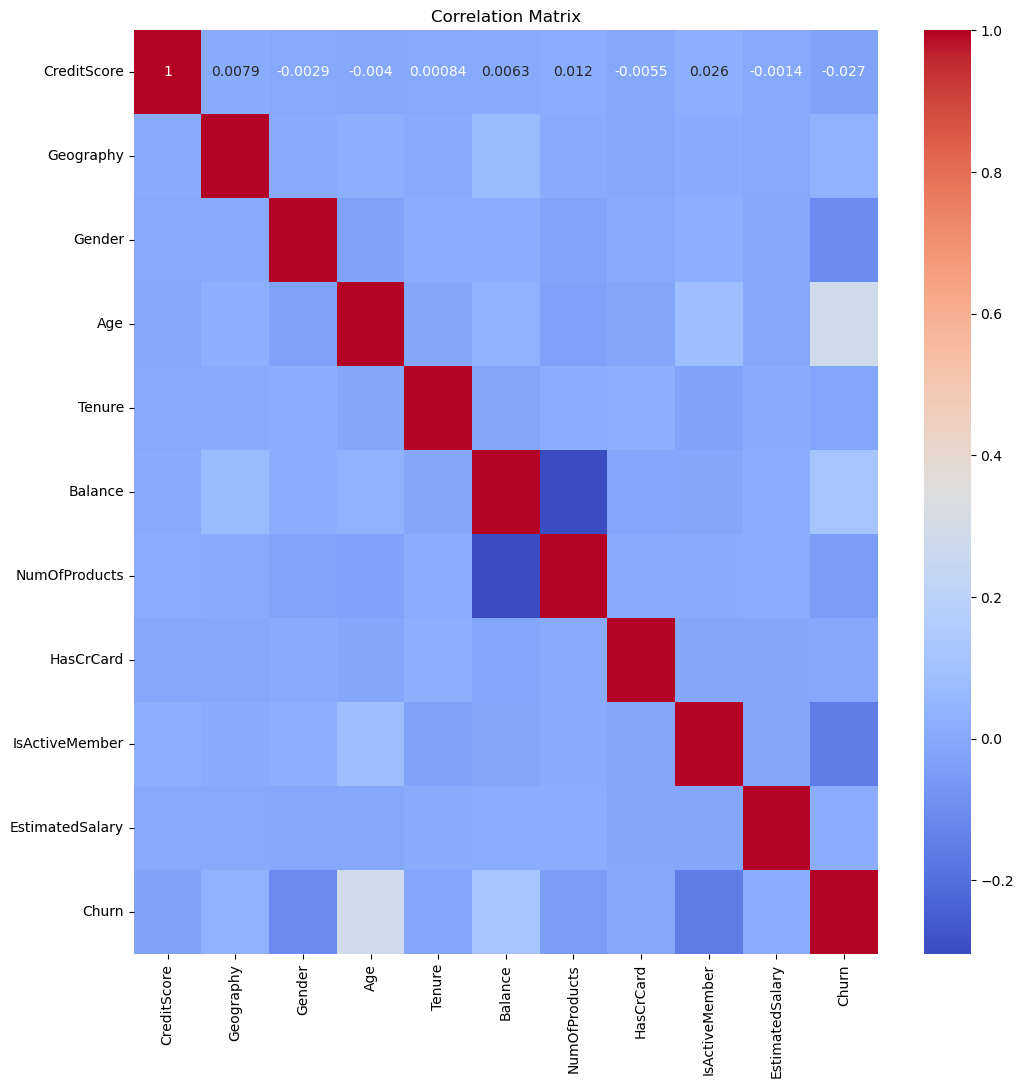

In [28]:
plt.figure(figsize=(12,12))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

There is no significant coorelation among the variables. So, I will proceed to model
building.

### Train Test Split

In [29]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Churn', axis=1), df['Churn'], test_size=0.2)

### Churn Prediction

For predicting the churn of customers, depending on the data of the customers, we will
use the following models:
Decision Tree Classifier
Random Forest Classifier

### Decision Tree Classifier

using gridsearchcv to find the best parameters for the model

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# creating decision tree classifier object
dtree = DecisionTreeClassifier()

#defining parameter range 
param_grid = {
    'max_depth' : [2,4,6,8,10,12,14,16,18,20],
    'min_samples_leaf': [1,2,3,4,5,6,7,8,9,10],
    'criterion': ['gini', 'entropy'],
    'random_state':[0,42]
}

# creating grid search object 
grid_dtree = GridSearchCV(dtree, param_grid, cv=5, scoring="roc_auc", n_jobs = -1, 
                          verbose=1)

# fitting the grid search object to the training data 
grid_dtree.fit(X_train, y_train)

#printing the best parameters
print("Best parameter found: ", grid_dtree.best_params_)

Fitting 5 folds for each of 400 candidates, totalling 2000 fits
Best parameter found:  {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 8, 'random_state': 42}


In [33]:
dtree = DecisionTreeClassifier(criterion="gini", max_depth=6, random_state=42, min_samples_leaf=10)
dtree

DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, random_state=42)

In [34]:
# training the model 
dtree.fit(X_train, y_train)

#training accuracy
dtree.score(X_train, y_train)

0.86

Predicting Customer Churn from test data 

In [35]:
dtree_pred = dtree.predict(X_test)

## Random Forest Classifier

In [37]:
from sklearn.ensemble import RandomForestClassifier

# creating rfc object
rfc = RandomForestClassifier()

#defining parameter range
param_grid = {
    'max_depth' : [2,4,6,8,10],
    'min_samples_leaf' : [2,4,6,8,10],
    'criterion' : ['gini', 'entropy'],
    'random_state':[0,42]}

# Creating grid search object 
grid_rfc = GridSearchCV(rfc, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, 
                        verbose=1)

# fitting the grid search object to the training data 
grid_rfc.fit(X_train, y_train)

# print the best parameters 
print("Best parameters found: ", grid_rfc.best_params_)



Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters found:  {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 8, 'random_state': 0}


In [38]:
rfc = RandomForestClassifier(min_samples_leaf=8, max_depth=10, random_state=10, criterion='entropy')

In [39]:
rfc

RandomForestClassifier(criterion='entropy', max_depth=10, min_samples_leaf=8,
                       random_state=10)

In [40]:
# training the model
rfc.fit(X_train, y_train)

# model accuracy
rfc.score(X_train, y_train)

0.880625

### predicting the customer churn from test set

In [41]:
rfc_pred = rfc.predict(X_test)

### Model Evaluation

### Decision Tree Classifier

confusion matrix heatmap

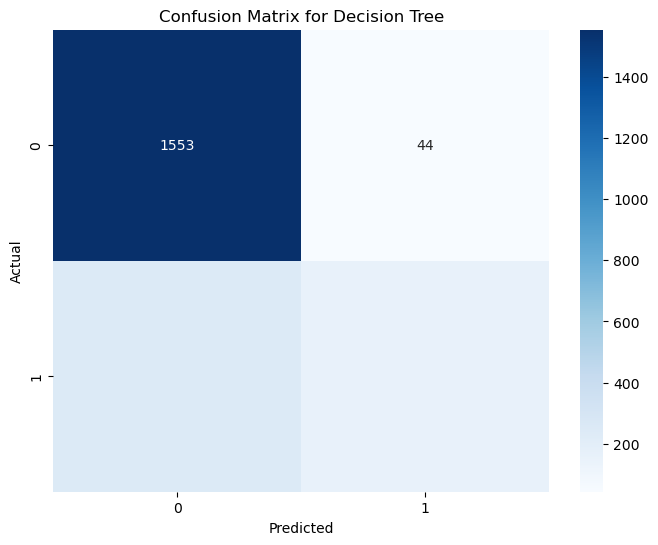

In [42]:
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, dtree_pred), annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Decision Tree")
plt.show()

The True Positive shows the count of correctly classified data points whereas the False Positive elements are those that are misclassified by the model. The higher the True Positive values of the confusion matrix the better, indicating many correct predictions.

## Distribution Plot

C:\Users\memun\AppData\Local\Temp\ipykernel_26212\2799666733.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(y_test, hist=False, color="r", label="Actual Value")
C:\Users\memun\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\memun\AppData\Local\Temp\ipykernel_26212\2799666733.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displ

<Axes: xlabel='Churn', ylabel='Density'>

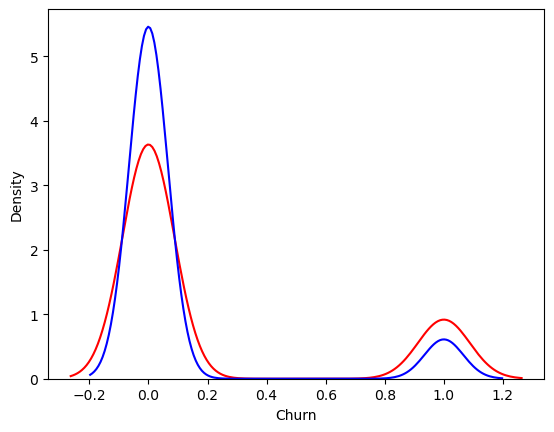

In [43]:
ax = sns.distplot(y_test, hist=False, color="r", label="Actual Value")
sns.distplot(dtree_pred, hist=False, color="b", label="Fitted Values" , ax=ax)

### Classification Report

In [44]:
from sklearn.metrics import classification_report
print(classification_report(y_test, dtree_pred))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1597
           1       0.78      0.39      0.52       403

    accuracy                           0.85      2000
   macro avg       0.82      0.68      0.72      2000
weighted avg       0.85      0.85      0.84      2000



In [45]:
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score
print("Accuracy Score: ", accuracy_score(y_test, dtree_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test, dtree_pred))
print("R2 Score: ", r2_score(y_test, dtree_pred))

Accuracy Score:  0.855
Mean Absolute Error:  0.145
R2 Score:  0.09880654017846757


### Random Forest Classifier

#### Confusion Matrix Heatmap

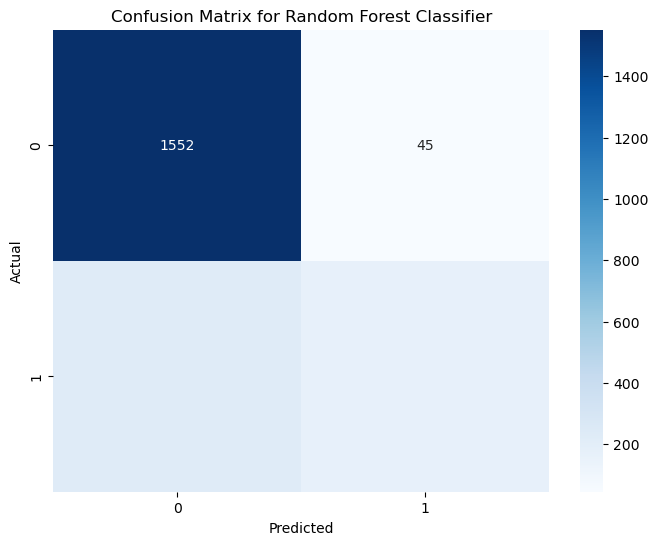

In [46]:


plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,rfc_pred),annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()


The True Positive shows the count of correctly classified data points whereas the False Positive elements are those that are misclassified by the model. The higher the True Positive values of the confusion matrix the better, indicating many correct predictions.

### Distribution Plot

C:\Users\memun\AppData\Local\Temp\ipykernel_26212\941622318.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(y_test, hist=False, color="r", label="Actual Value")
C:\Users\memun\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\memun\AppData\Local\Temp\ipykernel_26212\941622318.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot

<Axes: xlabel='Churn', ylabel='Density'>

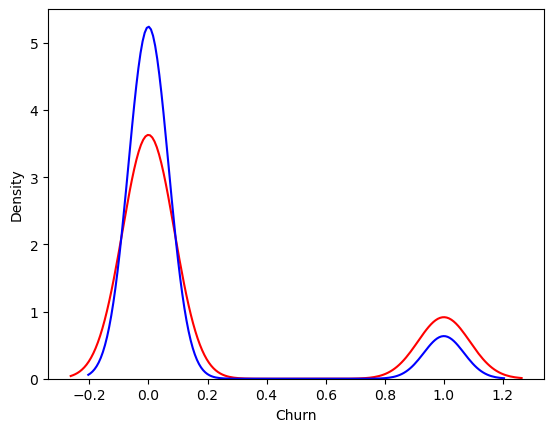

In [47]:
ax = sns.distplot(y_test, hist=False, color="r", label="Actual Value")
sns.distplot(rfc_pred, hist=False, color="b", label="Fitted Values" , ax=ax)


### Classification Report

In [48]:


from sklearn.metrics import classification_report
print(classification_report(y_test, rfc_pred))


              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1597
           1       0.79      0.42      0.55       403

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



In [49]:
print("Accuracy Score: ", accuracy_score(y_test, rfc_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test, rfc_pred))
print("R2 Score: ", r2_score(y_test, rfc_pred))

Accuracy Score:  0.8615
Mean Absolute Error:  0.1385
R2 Score:  0.13920486768770868
